In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)####忽略警告

In [2]:
setwd("/home/ljpuser/disk1/pienapple/03eye/30data_st_del/04imeta_fige_plot_update/04fig3/")

In [3]:
sp <- readRDS("/home/ljpuser/disk1/pienapple/03eye/30data_st_del/02data_del_nor/08RDS_mer_red/merge_red.RDS")

In [ ]:
sp1 <- subset(sp,subset=area%in%c("GCL","INL","ONL"))

In [14]:
#####Gene and microglia 分布
sp1 <- subset(sp,subset = area%in%c("GCL","INL","ONL"))
sp1

An object of class Seurat 
24382 features across 95980 samples within 1 assay 
Active assay: RNA (24382 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

In [16]:
sp2 <- subset(sp1,subset=celltype=="Microglia")

In [19]:
table(sp2@meta.data$sample)


 RIR1  RIR2  RIR3  RIR4  RIR5  RIR6 Sham1 Sham2 Sham3 Sham4 Sham5 
   99   173    81    56    91    20     7    10     8     6     4 

In [20]:
Idents(sp2) <- as.factor(sp2@meta.data$area)

In [30]:
deg <- FindAllMarkers(sp2,slot = "scale.data")

Calculating cluster GCL

Calculating cluster INL

Calculating cluster ONL



In [ ]:
deg1 <- deg[which(deg$avg_log2FC>1&deg$p_val_adj<0.05&deg$`pct.1`>0.2),]
deg1

In [33]:
unique(deg1$gene)

[1] "Cdk8"          "Camk1d"        "Il31ra"        "Gphn"         
 [5] "Apoe"          "Filip1l"       "Jarid2"        "Gm19951"      
 [9] "Cd44"          "Gm15564"       "Ctss"          "Gm48099"      
[13] "Scg2"          "Diras2"        "A230057D06Rik" "Rogdi"        
[17] "Wbp2"          "Adgrl3"        "Gngt1"         "Rho"          
[21] "Rbp3"          "Pdc"           "Pde6b"         "Sag"          
[25] "Tma7"          "Abca4"         "Aipl1"         "Hmox1"        
[29] "Nr2e3"         "Ndufa4"        "Pde6g"         "Hmgn1"        
[33] "Rcvrn"         "Guca1a"        "Prph2"

In [141]:
gene <- c('Cdk8','Camk1d','Il31ra','Gphn','Apoe','Filip1l','Jarid2','Gm19951','Cd44','Gm15564','Ctss','Scg2','Diras2','A230057D06Rik','Rogdi','Wbp2','Adgrl3',"Tmem119","Hexb","C1qa","C1qb","Ms4a7","P2ry12",
          'Gngt1','Rho','Rbp3','Pdc','Pde6b','Sag','Tma7','Abca4','Aipl1','Hmox1','Nr2e3','Ndufa4','Pde6g','Hmgn1','Rcvrn','Guca1a','Prph2')

In [142]:
mean_gene_exp<-AverageExpression(sp2,features=gene,group.by='area',slot='data')%>%data.frame()%>%as.matrix()
head(mean_gene_exp)

,RNA.GCL,RNA.INL,RNA.ONL
A230057D06Rik,-0.12160617,0.5887878,-0.11131396
Abca4,-0.27635375,-0.3296359,0.08126078
Adgrl3,-0.06932282,0.4663660,-0.17611975
Aipl1,-0.27850486,-0.2354596,0.07133757
Apoe,2.42630452,2.3954451,0.69745065
C1qa,2.93640206,2.1823962,1.53940030


In [143]:
# add colnames
colnames(mean_gene_exp) <- c("GCL","INL","ONL")

# Z-score
htdf <- t(scale(t(mean_gene_exp),scale = T,center = T))

# color
col_fun = colorRamp2(c(-2, 0, 2), c("#0099CC", "white", "#CC0033"))
cols <- c("ONL"="#B8DBB3","INL"="#2b6a99","GCL"="#f16c23")
# top annotation
column_ha = HeatmapAnnotation(cluster = colnames(htdf),col = list(cluster = cols))

In [145]:
colnames(m)

[1] "A230057D06Rik" "Abca4"         "Adgrl3"        "Aipl1"        
 [5] "Apoe"          "C1qa"          "C1qb"          "Camk1d"       
 [9] "Cd44"          "Cdk8"          "Ctss"          "Diras2"       
[13] "Filip1l"       "Gm15564"       "Gm19951"       "Gm48099"      
[17] "Gngt1"         "Gphn"          "Guca1a"        "Hexb"         
[21] "Hmgn1"         "Hmox1"         "Il31ra"        "Jarid2"       
[25] "Ms4a7"         "Ndufa4"        "Nr2e3"         "Pdc"          
[29] "Pde6b"         "Pde6g"         "Prph2"         "Rbp3"         
[33] "Rcvrn"         "Rho"           "Rogdi"         "Sag"          
[37] "Scg2"          "Tma7"          "Tmem119"       "Wbp2"

In [146]:
m <- as.data.frame(t(htdf))

In [147]:
gene <- c("C1qa",'Cdk8','Filip1l','Ctss','Gphn','Jarid2','Camk1d','Il31ra','Scg2','Apoe','Cd44',"Ms4a7","C1qb","P2ry12",
          'Diras2','Rogdi','Wbp2','Adgrl3',"Tmem119","Hexb",'Gngt1','Rho','Rbp3','Pdc','Pde6b','Sag','Tma7','Abca4','Aipl1','Hmox1','Nr2e3','Ndufa4','Pde6g','Hmgn1','Rcvrn','Guca1a','Prph2')

In [151]:
m1 <- subset(m,select =gene)

In [152]:
df <- t(m1)

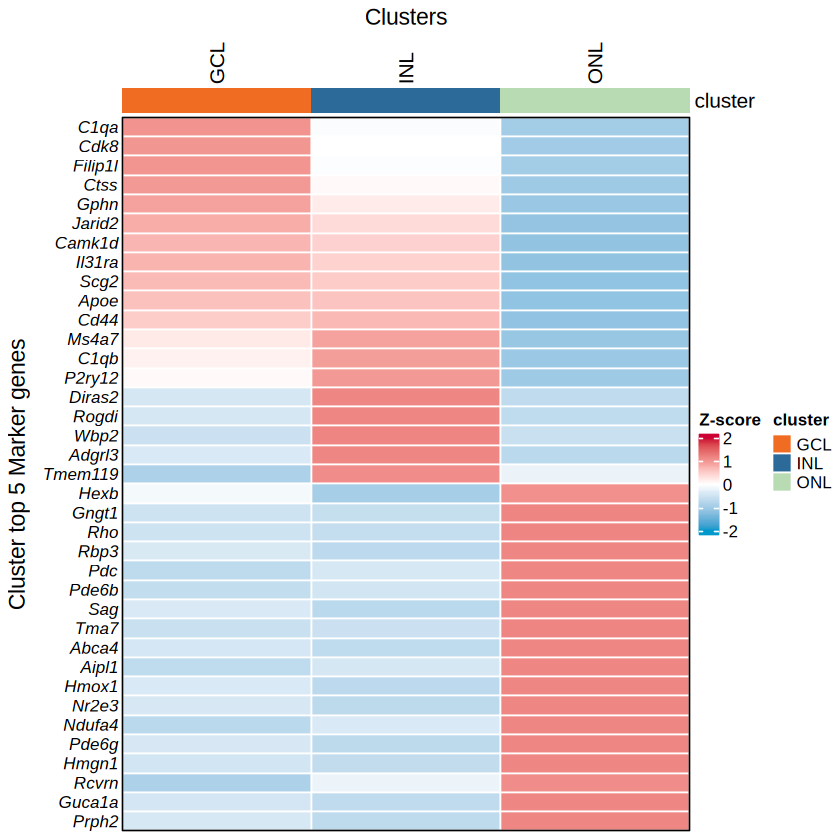

In [156]:
df <- subset(df,select = c("GCL","INL","ONL"))
p <- Heatmap(df,
        name = "Z-score",
        cluster_columns = F,cluster_rows = F,
        row_title = "Cluster top 5 Marker genes",
        column_title = "Clusters",
        row_names_gp = gpar(fontface = 'italic',fontsize = 10),
        row_names_side = 'left',
        border = T,
        rect_gp = gpar(col = "white", lwd = 1),
        column_names_side = 'top',
        column_names_rot = 90,
        top_annotation = column_ha,
        # column_split = paste('clsuter ',0:8,sep = ''),
        col = col_fun)
p
ggsave("heatmap_microglia_deg.pdf",width = 6,height = 8)

In [157]:
pdf("heatmap_microglia_deg.pdf",width = 6,height = 8)
print(p)
dev.off()

pdf 
  2